In [1]:
import tensorflow as tf

In [51]:
from tensorflow.keras.layers import Conv2D, Concatenate, Input, Activation,Dense, LeakyReLU,UpSampling2D
from tensorflow.keras.layers import Reshape, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [11]:
import sys
sys.path.append("..")
from dataset import make_sr_dataset
from pathlib import Path

In [4]:
print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.18.1
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("Metal GPU je spreman.")
else:
    print("TensorFlow i dalje radi samo na CPU.")

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Metal GPU je spreman.


In [6]:
np.random.seed(7)

In [7]:
#Globalne promenljive
HR_SIZE = 128
SCALE = 2
LR_SIZE = 64
BATCH = 32
EPOCHS = 100

In [12]:
#Pravljenje liste tipa string od svih podataka
ROOT = Path("../data/raw/Flickr2K")
path = [str(p) for p in ROOT.glob('*.png')]

In [14]:
np.random.shuffle(path)

In [15]:
#Podela na train test, val u odnosu 80% 10% 10%
train_paths = path[:2120]
val_paths = path[2120:2120+265]
test_paths = path[2120+265 :]

In [16]:
#Pravljenje tenzora putem dataset.py fajla za train i val
ds_train = make_sr_dataset(train_paths,HR_SIZE,SCALE,BATCH,True)
ds_val = make_sr_dataset(val_paths,HR_SIZE,SCALE,BATCH,False)

2026-03-14 19:37:58.844525: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-03-14 19:37:58.844629: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-03-14 19:37:58.844638: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.72 GB
I0000 00:00:1773513478.844729   30933 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1773513478.844836   30933 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [18]:
#definisanje ulaznih parametara 
input_shape = (64,64,3)
kernel_size = 3
layer_filters = [32, 64,128]

In [34]:
def dense_block(x,filters):
    x1 = Conv2D(filters = filters,kernel_size = kernel_size,padding = 'same',activation = LeakyReLU(0.2))(x)
    c2 = Concatenate()([x,x1])
    x2 = Conv2D(filters = filters,kernel_size = kernel_size,padding = 'same',activation = LeakyReLU(0.2))(c2)
    c3 = Concatenate()([x,x1,x2])
    x3 = Conv2D(filters = filters,kernel_size = kernel_size,padding = 'same',activation = LeakyReLU(0.2))(c3)
    c4 = Concatenate()([x,x1,x2,x3])
    x4 = Conv2D(filters = filters,kernel_size = kernel_size,padding = 'same',activation = LeakyReLU(0.2))(c4)
    c5 = Concatenate()([x,x1,x2,x3,x4])
    x5 = Conv2D(filters = filters,kernel_size = kernel_size,padding = 'same')(c5)

    output = x + 0.2 * x5

    return output

In [35]:
dummy = tf.random.normal((1,64,64,64))
y= dense_block(dummy,64) 
print(y.shape)

(1, 64, 64, 64)


In [36]:
def rrdb_block(x,filters):
    y =dense_block(x,filters)
    y =dense_block(y,filters)
    y =dense_block(y,filters)

    output = x +0.2 * y

    return output

In [37]:
dummy = tf.random.normal((1,64,64,64))
y= rrdb_block(dummy,64) 
print(y.shape)

(1, 64, 64, 64)


In [40]:
def build_gen(input_shape, filters = 64, num_rrdb = 8):
    inputs = Input(shape = input_shape)
    x = Conv2D(filters, kernel_size, padding='same')(inputs)

    x_skip = x

    for _ in range(num_rrdb):
        x = rrdb_block(x,filters)

    x = Conv2D(filters = filters, kernel_size = kernel_size, padding = 'same')(x)

    x = x + x_skip

    x = UpSampling2D(size = 2)(x)
    x = Conv2D(filters = filters, kernel_size = kernel_size, padding = 'same', activation = LeakyReLU(0.2))(x)

    outputs = Conv2D(3, kernel_size = kernel_size, padding='same', activation='sigmoid')(x)

    model = Model(inputs,outputs)
    
    return model

In [41]:
gen = build_gen((64, 64, 3))
gen.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 64, 64,    │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_26[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_20      │ (None, 64, 64,    │          0 │ conv2d_26[0][0],  │
│ (Concatenate)       │ 128)              │            │ conv2d_27[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 64, 64,    │     73,792 │ concatenate_20[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_21      │ (None, 64, 64,    │          0 │ conv2d_26[0][0],  │
│ (Concatenate)       │ 192)              │            │ conv2d_27[0][0],  │
│                     │                   │            │ conv2d_28[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 64, 64,    │    110,656 │ concatenate_21[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_22      │ (None, 64, 64,    │          0 │ conv2d_26[0][0],  │
│ (Concatenate)       │ 256)              │            │ conv2d_27[0][0],  │
│                     │                   │            │ conv2d_28[0][0],  │
│                     │                   │            │ conv2d_29[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 64, 64,    │    147,520 │ concatenate_22[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_23      │ (None, 64, 64,    │          0 │ conv2d_26[0][0],  │
│ (Concatenate)       │ 320)              │            │ conv2d_27[0][0],  │
│                     │                   │            │ conv2d_28[0][0],  │
│                     │                   │            │ conv2d_29[0][0],  │
│                     │                   │            │ conv2d_30[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 64, 64,    │    184,384 │ concatenate_23[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 64, 64,    │          0 │ conv2d_31[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64,    │          0 │ conv2d_26[0][0],  │
│                     │ 64)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 64, 64,    │     36,928 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_24      │ (None, 64, 64,    │          0 │ add[0][0],      

 Total params: 13,356,099 (50.95 MB)

 Trainable params: 13,356,099 (50.95 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
for lr, hr in ds_train.take(1):
    sr = gen(lr)
    print("LR:", lr.shape)
    print("SR:", sr.shape)
    print("HR:", hr.shape)

LR: (32, 64, 64, 3)
SR: (32, 128, 128, 3)
HR: (32, 128, 128, 3)


2026-03-14 21:45:09.252523: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [43]:
gen = build_gen((LR_SIZE, LR_SIZE, 3))

In [49]:
gen.compile(optimizer = Adam(learning_rate = 1e-4),loss = 'MAE')

2026-03-14 21:58:38.335292: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


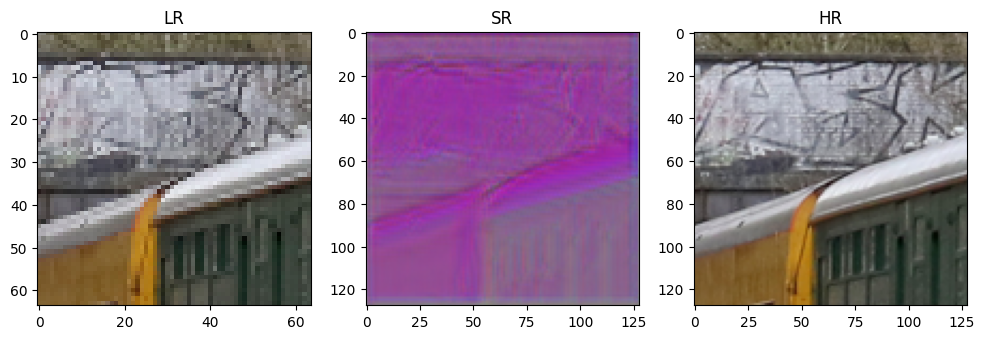

2026-03-14 21:58:39.475667: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [50]:
import matplotlib.pyplot as plt

for lr, hr in ds_train.take(1):
    sr = gen.predict(lr)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("LR")
    plt.imshow(lr[0])

    plt.subplot(1,3,2)
    plt.title("SR")
    plt.imshow(sr[0])

    plt.subplot(1,3,3)
    plt.title("HR")
    plt.imshow(hr[0])

    plt.show()

In [54]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath="../models/'best_generator_pretrain_esrgan.keras",
        monitor='val_loss',
        save_best_only=True
    )
]

In [57]:
history = gen.fit(
    ds_train,
    validation_data = ds_val,
    epochs = EPOCHS,
    callbacks = callbacks,
    verbose = 1
)

Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - loss: 0.1568 - val_loss: 0.0872
Epoch 2/100
28/66 ━━━━━━━━━━━━━━━━━━━━ 1:16 2s/step - loss: 0.0934

KeyboardInterrupt: 